In [71]:
import numpy as np
import h5py
import json
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [72]:
h5_path = "../data/raw/TheCycloneImageDataset/Cyclone_Images.h5"   # apna exact path confirm kar lena

train_idx = np.load("../data/processed/train_idx.npy")
val_idx = np.load("../data/processed/val_idx.npy")
test_idx = np.load("../data/processed/test_idx.npy")
encoded_labels = np.load("../data/processed/encoded_labels.npy")

with open("../data/processed/category_mapping.json") as f:
    category_mapping = json.load(f)

num_classes = len(np.unique(encoded_labels))
print("Num classes:", num_classes)
print("Train:", len(train_idx), "Val:", len(val_idx), "Test:", len(test_idx))

Num classes: 6
Train: 14753 Val: 3161 Test: 3162


In [73]:
def find_corrupt_indices(h5_path, indices, chunk=2000):
    corrupt = []
    indices_sorted = np.sort(indices)

    with h5py.File(h5_path, 'r') as f:
        images_ds = f['Images']
        for start in range(0, len(indices_sorted), chunk):
            batch_idx = indices_sorted[start:start+chunk]
            batch = images_ds[batch_idx].astype('float32')

            bad_mask = np.isnan(batch).any(axis=(1,2,3)) | np.isinf(batch).any(axis=(1,2,3))
            bad_indices = batch_idx[bad_mask]
            corrupt.extend(bad_indices.tolist())

    return np.array(corrupt)

corrupt_train = find_corrupt_indices(h5_path, train_idx)
corrupt_val = find_corrupt_indices(h5_path, val_idx)

print("Corrupt in train:", len(corrupt_train), "out of", len(train_idx))
print("Corrupt in val:", len(corrupt_val), "out of", len(val_idx))

Corrupt in train: 13 out of 14753
Corrupt in val: 4 out of 3161


In [74]:
train_idx_clean = np.array([i for i in train_idx if i not in set(corrupt_train)])
val_idx_clean = np.array([i for i in val_idx if i not in set(corrupt_val)])

print("Train:", len(train_idx), "->", len(train_idx_clean))
print("Val:", len(val_idx), "->", len(val_idx_clean))

Train: 14753 -> 14740
Val: 3161 -> 3157


In [75]:
class CycloneDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, h5_path, indices, labels, batch_size=32, shuffle=True):
        self.h5_path = h5_path
        self.indices = indices
        self.labels = labels
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        return len(self.indices) // self.batch_size

    def __getitem__(self, idx):
        batch_indices = self.indices[idx*self.batch_size : (idx+1)*self.batch_size]
        batch_indices_sorted = np.sort(batch_indices)

        with h5py.File(self.h5_path, 'r') as f:
            images = f['Images'][batch_indices_sorted].astype('float32') / 255.0

        labels = self.labels[batch_indices_sorted]
        return images, labels

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

In [76]:
train_gen = CycloneDataGenerator(h5_path, train_idx_clean, encoded_labels, batch_size=32, shuffle=True)
val_gen = CycloneDataGenerator(h5_path, val_idx_clean, encoded_labels, batch_size=32, shuffle=False)

print("Batches per epoch (train):", len(train_gen))
print("Batches per epoch (val):", len(val_gen))

Batches per epoch (train): 460
Batches per epoch (val): 98


In [77]:
model = models.Sequential([
    layers.Input(shape=(128, 128, 4)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [78]:
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [79]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    verbose=1
)

Epoch 1/20


/Users/chessinorbit/Desktop/CYCLONE-PREDICTION/venv/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


460/460 ━━━━━━━━━━━━━━━━━━━━ 36s 75ms/step - accuracy: 0.3718 - loss: 24.5789 - val_accuracy: 0.4697 - val_loss: 8.8467
Epoch 2/20
460/460 ━━━━━━━━━━━━━━━━━━━━ 34s 74ms/step - accuracy: 0.4257 - loss: 22.9629 - val_accuracy: 0.5226 - val_loss: 8.3300
Epoch 3/20
460/460 ━━━━━━━━━━━━━━━━━━━━ 34s 73ms/step - accuracy: 0.4461 - loss: 12.8897 - val_accuracy: 0.5188 - val_loss: 4.9922
Epoch 4/20
460/460 ━━━━━━━━━━━━━━━━━━━━ 35s 76ms/step - accuracy: 0.4664 - loss: 6.6014 - val_accuracy: 0.5482 - val_loss: 2.5424
Epoch 5/20
460/460 ━━━━━━━━━━━━━━━━━━━━ 39s 84ms/step - accuracy: 0.4772 - loss: 4.1890 - val_accuracy: 0.5099 - val_loss: 2.0604
Epoch 6/20
460/460 ━━━━━━━━━━━━━━━━━━━━ 43s 94ms/step - accuracy: 0.4948 - loss: 2.8209 - val_accuracy: 0.5523 - val_loss: 1.6807
Epoch 7/20
460/460 ━━━━━━━━━━━━━━━━━━━━ 42s 91ms/step - accuracy: 0.5082 - loss: 2.1210 - val_accuracy: 0.5689 - val_loss: 1.3444
Epoch 8/20
460/460 ━━━━━━━━━━━━━━━━━━━━ 41s 90ms/step - accuracy: 0.5246 - loss: 1.6755 - val_accu

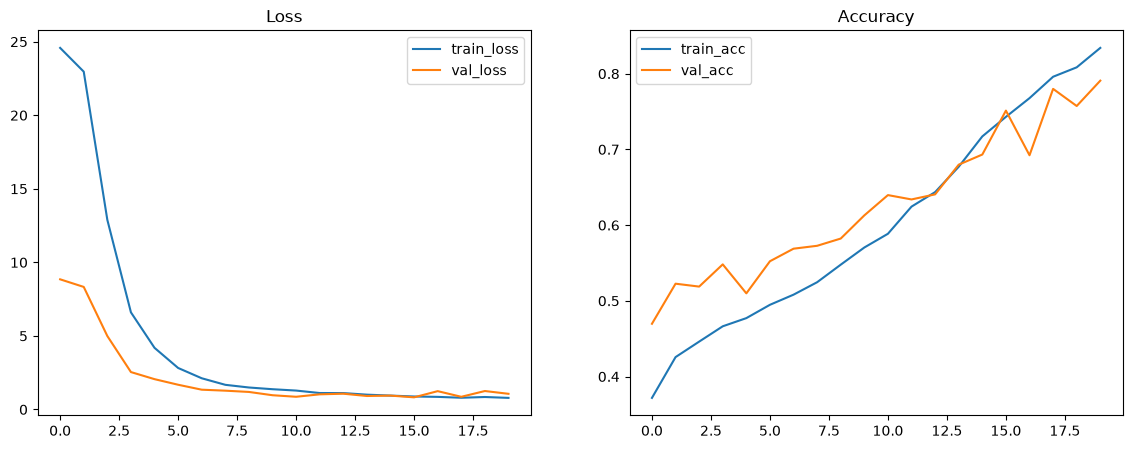

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='train_loss')
axes[0].plot(history.history['val_loss'], label='val_loss')
axes[0].set_title('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='train_acc')
axes[1].plot(history.history['val_accuracy'], label='val_acc')
axes[1].set_title('Accuracy')
axes[1].legend()

plt.show()

In [83]:
import os
os.makedirs("../models", exist_ok=True)
model.save("../models/baseline_cnn_final.keras")
print("Model saved!")

Model saved!


98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step


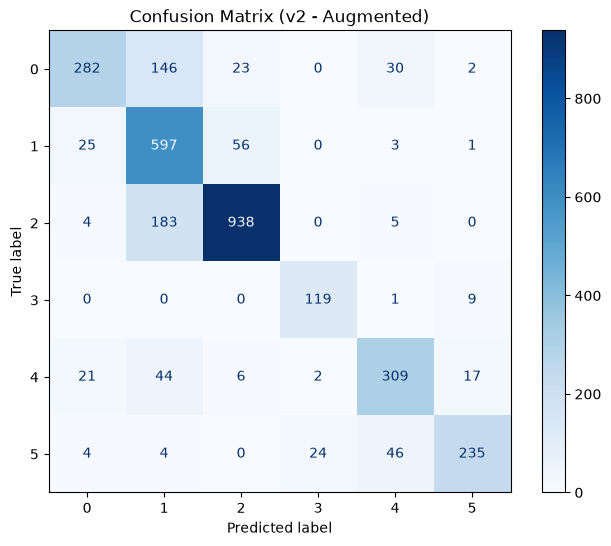

              precision    recall  f1-score   support

           0       0.84      0.58      0.69       483
           1       0.61      0.88      0.72       682
           2       0.92      0.83      0.87      1130
           3       0.82      0.92      0.87       129
           4       0.78      0.77      0.78       399
           5       0.89      0.75      0.81       313

    accuracy                           0.79      3136
   macro avg       0.81      0.79      0.79      3136
weighted avg       0.82      0.79      0.79      3136



In [82]:
val_preds = model.predict(val_gen)
val_pred_labels = np.argmax(val_preds, axis=1)

val_true_labels = []
for i in range(len(val_gen)):
    batch_indices = val_gen.indices[i*val_gen.batch_size : (i+1)*val_gen.batch_size]
    batch_indices_sorted = np.sort(batch_indices)
    val_true_labels.extend(val_gen.labels[batch_indices_sorted])
val_true_labels = np.array(val_true_labels)

cm = confusion_matrix(val_true_labels, val_pred_labels)

fig, ax = plt.subplots(figsize=(8,6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix (v2 - Augmented)')
plt.show()

print(classification_report(val_true_labels, val_pred_labels))